### IMPORT MODEULES

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

### Adding gaussian noise and slat/pepper on original

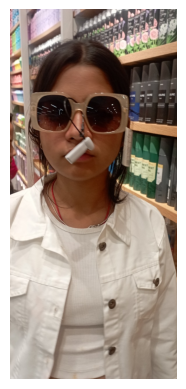

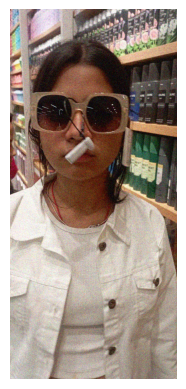

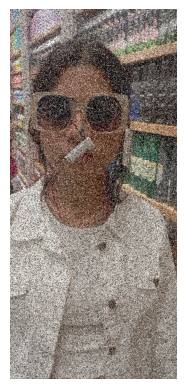

True

In [ ]:
original = cv.imread(r"data\original.jpg")
original_rgb=cv.cvtColor(original,cv.COLOR_BGR2RGB)
plt.imshow(original_rgb)
plt.axis("off")
plt.show()
original_rgb=original_rgb.astype(np.float32)

# =========gaussian noise=========
mean=0
sigma=25

noise=np.random.normal(mean,sigma,original_rgb.shape)

noisy=original_rgb+noise

noisy=np.clip(noisy,0,255)
noisy=noisy.astype(np.uint8)

plt.imshow(noisy)
plt.axis("off")
plt.show()
cv.imwrite(r"data/noisy_gaussian.jpeg",cv.cvtColor(noisy,cv.COLOR_BGR2RGB))

#==========salt/pepper noise=============

noisy_sp=original_rgb.copy()

noise_amnt=0.5

total_pixels=original_rgb.shape[0]*original_rgb.shape[1]

num_pixels=int(noise_amnt*total_pixels)


salty_x=np.random.randint(0,original_rgb.shape[1],num_pixels//2)
salty_y=np.random.randint(0,original_rgb.shape[0],num_pixels//2)

noisy_sp[salty_y, salty_x] = 255

pepper_x=np.random.randint(0,original_rgb.shape[1],num_pixels//2)
pepper_y=np.random.randint(0,original_rgb.shape[0],num_pixels//2)

noisy_sp[pepper_y,pepper_x]=0

noisy_sp=noisy_sp.astype(np.uint8)

plt.imshow(noisy_sp)
plt.axis("off")
plt.show()

cv.imwrite(r"data/noisy_sp.jpeg",cv.cvtColor(noisy_sp,cv.COLOR_BGR2RGB))



### DENOISING

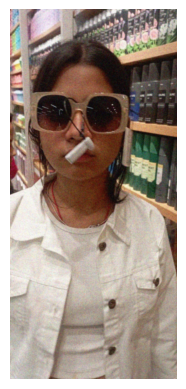

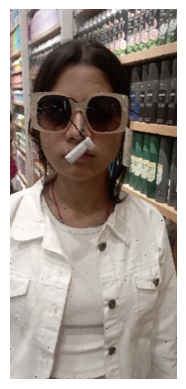

True

In [37]:
gaussian=cv.imread(r"data\noisy_gaussian.jpeg")
#gaussian_rgb=cv.cvtColor(gaussian,cv.COLOR_BGR2RGB)
sp=cv.imread(r"data\noisy_sp.jpeg")
#sp_rgb=cv.cvtColor(sp,cv.COLOR_BGR2RGB)

gaussian_denoised=cv.GaussianBlur(gaussian,(5,5),0)
plt.imshow(cv.cvtColor(gaussian_denoised, cv.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
cv.imwrite(r"data\gaussian_denoised.png",gaussian_denoised)


sp_denoised = cv.medianBlur(sp, 5)
plt.imshow(cv.cvtColor(sp_denoised,cv.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
cv.imwrite(r"data\sp_denoised.png",sp_denoised)


## MSE AND PSNR

In [42]:
original = cv.imread(r"data\original.jpg")

gaussian_denoised = cv.imread(r"data\gaussian_denoised.png")
sp_denoised = cv.imread(r"data\sp_denoised.png")


# Gaussian denoised
mse_gaussian = np.mean(
    (original.astype(np.float32) - gaussian_denoised.astype(np.float32)) ** 2
)

psnr_gaussian = cv.PSNR(original, gaussian_denoised)


# Salt & Pepper denoised
mse_sp = np.mean(
    (original.astype(np.float32) - sp_denoised.astype(np.float32)) ** 2
)

psnr_sp = cv.PSNR(original, sp_denoised)


print("Gaussian Denoising")
print("MSE  :", mse_gaussian)
print("PSNR :", psnr_gaussian, "dB")

print("\nSalt & Pepper Denoising")
print("MSE  :", mse_sp)
print("PSNR :", psnr_sp, "dB")

Gaussian Denoising
MSE  : 62.504837
PSNR : 30.17166687632843 dB

Salt & Pepper Denoising
MSE  : 132.74654
PSNR : 26.90057207939344 dB
